In [1]:
import torch
from torch import nn

torch.__version__

'2.10.0'

In [2]:
import kagglehub
device = "cuda" if torch.cuda.is_available() else "cpu"
# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/jenniferfu/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1


In [3]:
import os

print(os.listdir(path))

['training_set', 'test_set']


In [4]:
for root, dirs, files in os.walk(path):
    print(root)
    break

/Users/jenniferfu/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1


In [5]:
!pip install torchvision


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
# create transform

from torchvision.datasets import ImageFolder
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ToTensor()
])

dataset = ImageFolder(path, transform=transform)


In [7]:
dataset

Dataset ImageFolder
    Number of datapoints: 10028
    Root location: /Users/jenniferfu/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )

In [8]:
# turn into data_loader
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root=f"{path}/training_set/training_set",
    transform=transform
)

test_dataset = ImageFolder(
    root=f"{path}/test_set/test_set",
    transform=transform
)

In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [10]:
print(len(train_dataset))
print(len(test_dataset))

print(train_dataset.class_to_idx)
class_names = train_dataset.classes

8005
2023
{'cats': 0, 'dogs': 1}


In [11]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32])


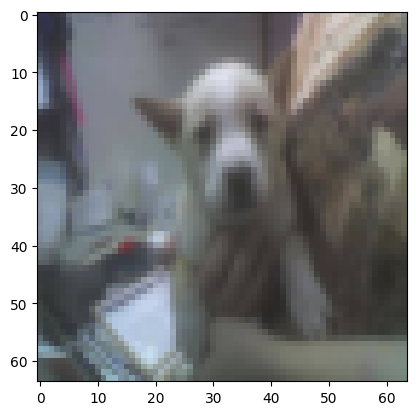

In [12]:
import matplotlib.pyplot as plt

img = images[0].permute(1,2,0)
plt.imshow(img)
plt.show()

In [13]:
# create the model

class TinyVGG(nn.Module):

  def __init__(self, input_shape: int, hidden_units: int, output_shape:int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        # create a conv layer
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2) # output the max of kernel
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride = 1,
                  padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2)

    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*13*13, # trick to calculating this
                  out_features=output_shape)
    )
  def forward(self, x):
    x = self.conv_block_1(x)
    # print(x.shape)
    x = self.conv_block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    # print(x.shape)
    return x

In [14]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, # number of colour channels
                  hidden_units=15,
                  output_shape=len(class_names)).to(device)


model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 15, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(15, 15, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(15, 15, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(15, 15, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2535, out_features=2, bias=True)
  )
)

In [15]:
# try a forward pass

image_batch, label_batch = next(iter(train_loader))

image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [16]:
model_0(image_batch.to(device))

tensor([[0.0240, 0.0214],
        [0.0237, 0.0162],
        [0.0207, 0.0176],
        [0.0217, 0.0203],
        [0.0209, 0.0194],
        [0.0201, 0.0217],
        [0.0221, 0.0241],
        [0.0201, 0.0209],
        [0.0207, 0.0196],
        [0.0218, 0.0217],
        [0.0247, 0.0186],
        [0.0227, 0.0187],
        [0.0234, 0.0190],
        [0.0196, 0.0192],
        [0.0224, 0.0184],
        [0.0230, 0.0172],
        [0.0198, 0.0201],
        [0.0199, 0.0191],
        [0.0242, 0.0157],
        [0.0232, 0.0205],
        [0.0197, 0.0251],
        [0.0186, 0.0225],
        [0.0201, 0.0220],
        [0.0201, 0.0198],
        [0.0204, 0.0194],
        [0.0242, 0.0212],
        [0.0183, 0.0216],
        [0.0195, 0.0199],
        [0.0233, 0.0183],
        [0.0219, 0.0183],
        [0.0207, 0.0207],
        [0.0223, 0.0164]], grad_fn=<AddmmBackward0>)

##Train and Test

In [17]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  total_time = end-start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.0001)


In [18]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device = device):

  model.train()
  train_loss, train_acc = 0, 0

  # loop through batches
  for batch, (X, y) in enumerate(data_loader):

    # put data on target device
    X = X.to(device)
    y = y.to(device)


    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss.item() # accumulate the loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class==y).sum().item()/len(y_pred)

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)

  # print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%")

  return train_loss, train_acc


In [19]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device = device):

  model.eval()
  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(data_loader):

      # put data on target device
      X = X.to(device)
      y = y.to(device)

      test_pred = model(X)
      loss = loss_fn(test_pred, y)
      test_loss += loss.item()
      test_pred_labels = test_pred.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # average per batch
  test_loss /= len(data_loader)
  test_acc /= len(data_loader)

    #print(f"Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")
  return test_loss, test_acc



In [20]:
from timeit import default_timer as timer
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader,
          test_dataloader,
          optimizer,
          loss_fn = nn.CrossEntropyLoss(),
          epochs=5,
          device=device):
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                       data_loader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       device=device)

    test_loss, test_acc = test_step(model=model,
                                    data_loader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device)

    print(f"Epoch: {epoch} | Train loss: {train_loss: .4f} | Train acc: {train_acc: .4f} | Test loss: {train_loss: .4f} | Test acc: {test_acc: .4f}")
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # return the filled results
  return results

In [21]:
torch.manual_seed(42)

NUM_EPOCHS=30
model_0 = TinyVGG(input_shape = 3,
                  hidden_units=10,
                  output_shape=2).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(),
                             lr=0.001)
start_time = timer()
model_0_results = train(model=model_0,
      train_dataloader=train_loader,
      test_dataloader=test_loader,
      optimizer=optimizer,
      loss_fn=loss_fn,
      epochs=NUM_EPOCHS)
end_time = timer()
print(f"total time: {end_time-start_time:.3f}")

  3%|█▍                                          | 1/30 [00:22<10:48, 22.37s/it]

Epoch: 0 | Train loss:  0.6943 | Train acc:  0.4958 | Test loss:  0.6943 | Test acc:  0.5525


  7%|██▉                                         | 2/30 [00:45<10:46, 23.07s/it]

Epoch: 1 | Train loss:  0.6903 | Train acc:  0.5402 | Test loss:  0.6903 | Test acc:  0.5371


 10%|████▍                                       | 3/30 [01:09<10:32, 23.43s/it]

...

Epoch: 27 | Train loss:  0.4888 | Train acc:  0.7663 | Test loss:  0.4888 | Test acc:  0.7135


 97%|█████████████████████████████████████████▌ | 29/30 [11:33<00:24, 24.04s/it]

Epoch: 28 | Train loss:  0.4867 | Train acc:  0.7666 | Test loss:  0.4867 | Test acc:  0.7355


100%|███████████████████████████████████████████| 30/30 [11:56<00:00, 23.89s/it]

Epoch: 29 | Train loss:  0.4837 | Train acc:  0.7751 | Test loss:  0.4837 | Test acc:  0.7257
total time: 716.765


In [ ]:
print("hi")

In [ ]:
print("HI")
model_0 = model_0.to("cpu")
torch.save(model_0.state_dict(), "./model_0.pth")
print("Saved!")

In [ ]:
%%writefile app.py
import streamlit as st
from PIL import Image
import torch
import torchvision.transforms as transforms

# Define model architecture again
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=2).to(device)

# Load weights
model_0.load_state_dict(torch.load("model_0.pth", map_location=device))

# Set to evaluation mode
model_0.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"

st.title("Cat vs Dog Classifier 🐱🐶")

# Example preprocessing
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


# Upload image
uploaded_file = st.file_uploader(
    "Upload an image of a cat or dog",
    type=["jpg","jpeg","png"]
)

if uploaded_file is not None:

    image = Image.open(uploaded_file)

    st.image(image, caption="Uploaded Image", use_column_width=True)

    img = transform(image).unsqueeze(0)
    img_pred = model_0(img.to(device))
    img_prob = torch.softmax(img_pred, dim=1)
    img_label = torch.argmax(img_prob, dim=1)

    # Example prediction (replace with your model)
    prediction = class_names[img_label]

    st.subheader("Prediction:")
    st.success(class_names[prediction])

In [ ]:
!streamlit run app.py

In [ ]:
!ls